We are using the theta method, an implicit method for solving ODEs. We apply the fourier transform to the cahn-hilliard equation giving us a linear np.expression for the time derivative of u. This can be concidered as our F(t, U). 
$$
\partial_{t}\hat{u} = \hat{g} - \kappa |\tilde{k}|^4\hat{u}
$$


As we are using an implicit method, we solve U(n+1) as shown in the theory. 

The code initially finds the sampling frequencies, then find the starting point in fourier space U0, at t0. We then sole the time dependent part of the differential equation using the solution of the linear equation mentioned. For each time step we yield the solution and time.

## Imports, solver, global variables, plot function

In [19]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd

In [ ]:
def transient_biharmonic_solver(*, kappa, X, Y, U0, t0, T, Nt, Lx, Ly, theta=0.5, g=None):

    # Lager frekvensrommet
    Nx, Ny = X.shape 
    kx = fftfreq(Nx, d=Lx/Nx)*2*np.pi
    ky = fftfreq(Ny, d=Ly/Ny)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, sparse=True)

    # Definerer k**4 til senere bruk
    k4 = (KX**2 + KY**2)**2

    # Finner initialbetingelsene i frekvensrommet og tidssteg
    U_hat0 = fft2(U0)
    U_hat = U_hat0
    t = t0
    dt = (T-t0)/Nt

    yield U_hat0, t     # Yielder init. bet. i frekvensrom
    
    if g is None:       # Håndterer tilfellet at g ikke er en kallbar funksjon (Homogen likning)
        g = lambda x, y, t: np.zeros_like(U_hat)
    
    while t < T-dt/2:
        g_now = fft2(g(X, Y, t))        # g(n)
        g_next = fft2(g(X , Y, t+dt))   # g(n+1)
        
        # Benytter løsning av lineær likning for å finne U(n+1) implisitt
        U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)
        
        t+=dt # Oppdaterer tid

        yield U_hat, t # Yielder nåværende løsning

#### Definerer variabler som forblir uendret gjennom hele oppgaven

In [23]:
Nx, Ny = 20, 20             # Antall romlige sampling punkter
Lx, Ly = 2*np.pi, 2*np.pi   # Størrelse på romlig domene
lam = 4                     # Den beregnede lambda som gir homogent tilfelle g=0
kappa = 1 
t0 = 0
T = 1

# Definerer romlig domene symmetrisk om origo
x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False) 
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')  # Shape: (Nx, Ny)


Nts = [10, 20, 40, 80, 160, 320, 640]

In [6]:
def plot(Uex,U):
    fig = plt.figure(figsize=(20, 5))
    ax = fig.add_subplot(131, projection='3d')
    surf = ax.plot_surface(X, Y, Uex, cmap='viridis', antialiased=True)
    fig.colorbar(surf, shrink=0.6)
    ax.set_title("Exact solution")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U_\mathrm{ex}$')

    ax = fig.add_subplot(132, projection='3d')
    surf = ax.plot_surface(X, Y, U, cmap='viridis')
    fig.colorbar(surf, shrink=0.6)
    ax.set_title("Numerical solution")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U(X, Y)$')


    print(f"Error norm: {np.linalg.norm(U_err)}")
    ax = fig.add_subplot(133, projection='3d')
    surf = ax.plot_surface(X, Y,  U_err, cmap='viridis')
    fig.colorbar(surf, shrink=0.6)
    ax.set_title("Error")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U-U_{\mathrm{ex}}$')

    fig.suptitle(f"Theta = {theta}, Nt = {Nt}", fontsize=16)
    plt.show()

In [ ]:
def error(Nts, thetas, u_ex, g=None): # Takes lists of Nt values and theta values, and callable u_ex and g
        Nts = np.array(Nts)
        theta = np.array(thetas)
        errors = np.zeros((len(thetas), len(Nts)))
        eocs = np.zeros((len(thetas), len(Nts)-1))
        U0 = u_ex(X, Y, t0)
        for i in range(len(thetas)):
                timeAndSpaceMax = np.zeros(len(Nts))
                for j in range(len(Nts)):
                        Nt = Nts[j]
                        theta = thetas[i]
                        solver = transient_biharmonic_solver(kappa=kappa, 
                                                                X=X, Y=Y, U0=U0, 
                                                                t0=t0, T=T, Nt=Nt,
                                                                Lx=Lx, Ly=Ly,
                                                                theta=theta,
                                                                g=g)
                        spacialMax = np.zeros(Nt+1)
                        k = 0
                        for Uhat, t in solver: 
                                
                                U = ifft2(Uhat).real # Finner U i fysisk rom ved invers fourier transform
                                spacialMax[k] = ((np.abs(u_ex(X, Y, t) - U).max())) # Finner størst feil ved tidssteget
                                k+=1
                        timeAndSpaceMax[j] = (spacialMax).max()
                errors[i] = timeAndSpaceMax
        
                eocs[i] = np.log(errors[i][1:]/errors[i][:-1])/np.log(Nts[:-1]/Nts[1:])
        return  errors, eocs # Returns (thetas x Nts) sized array with L inf errors and EOCs respectively for each thetas and Nt

def table(Nts, thetas, u_ex, g = None): # Takes lists of Nt values and theta values, and callable u_ex and g
        
        errors, eocs = error(Nts, thetas, u_ex, g=g)
        for i in range(len(errors)):
                df = pd.DataFrame()
                df['Nt'] = Nts
                df[f'L-inf error, θ = {thetas[i]}'] = errors[i]
                eoc_padded = np.append([np.nan], eocs[i])

                df[f'EOC, θ = {thetas[i]}'] = eoc_padded
                #df = df.style.set_caption(f"theta = {thetas[i]}").set_table_styles(styles)

                # show datafram in a better format
                display(df)

## A first tester solution

Error norm: 0.0006104192556393819


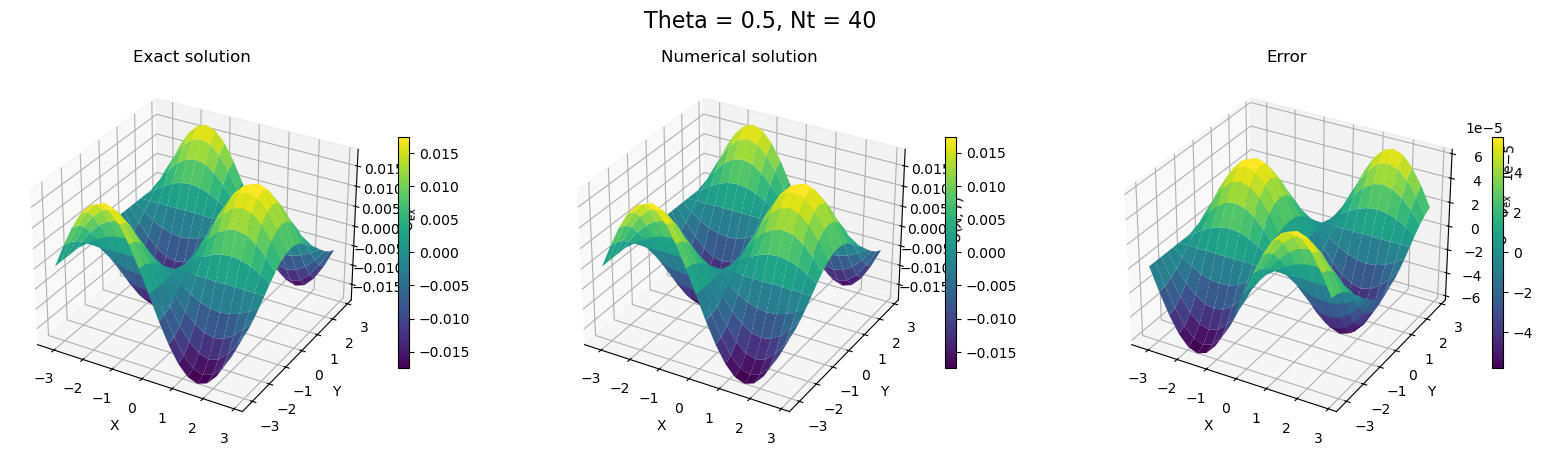

In [9]:
# Implementerer den første konstruerte løsningen
u_ex = lambda x, y, t: np.sin(x)*np.cos(y)*np.exp(-lam * kappa * t)

U0 = u_ex(X, Y, t0) # Initialbetingelse
theta = 0.5         
Nt = 40

solver = transient_biharmonic_solver(kappa=kappa, 
                                     X=X, Y=Y, U0=U0, 
                                     t0=t0, T=T, Nt=Nt,
                                     Lx=Lx, Ly=Ly,
                                     theta=theta,
                                     g=None)


# Itererer gjennom tuple objektet som gis av funksjonen og oppdaterer slik at vi plotter løsning ved T=1
for Uhat, t in solver: 
    
    U = ifft2(Uhat).real # Finner U i fysisk rom ved invers fourier transform
    Tfinal = t

Uex = u_ex(X, Y, Tfinal) # Beregner eksakt løsn. ved T=1 på samme fysiske domenet som num. løsn.

U_err = U - Uex # Finner enkel feil  til illustrasjon

plot(Uex, U)


## Theta = 1, 0.5, 0

Error norm: 0.009233187025514072


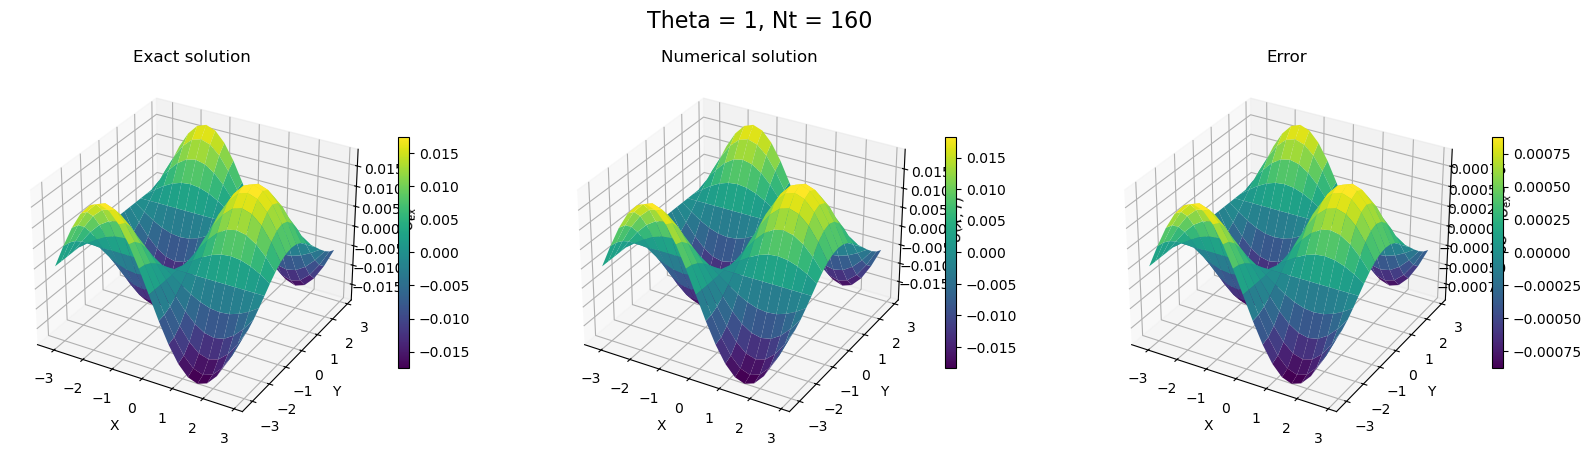

Error norm: 3.8157183473469986e-05


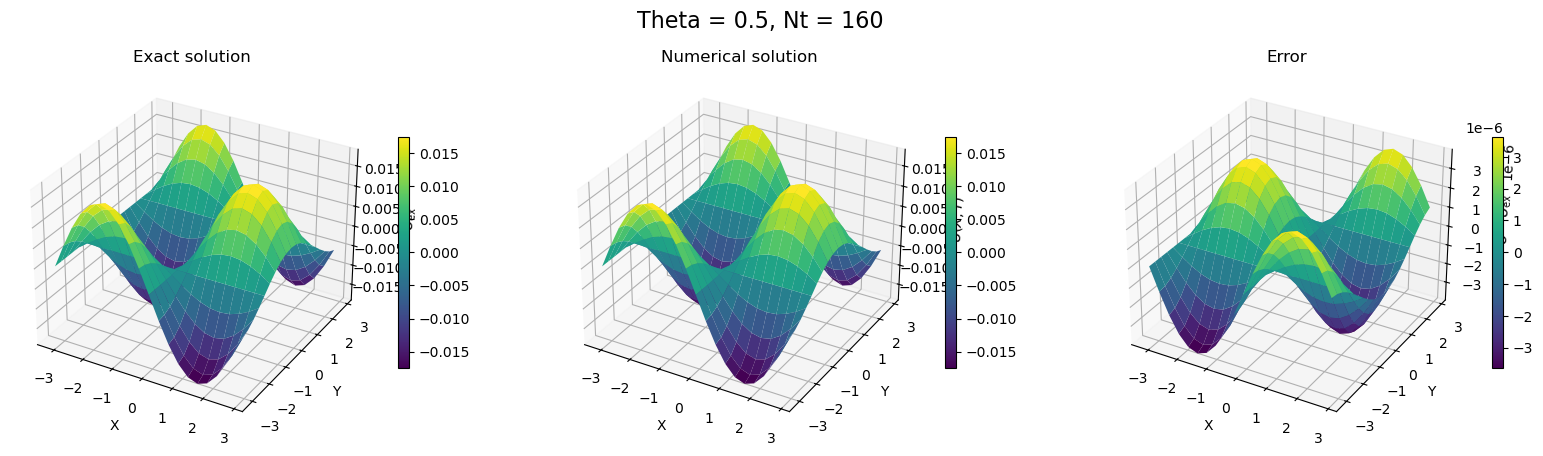

/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_1009/1387326174.py:28: RuntimeWarning: overflow encountered in multiply
  U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)
/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_1009/1387326174.py:28: RuntimeWarning: invalid value encountered in multiply
  U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)


Error norm: nan


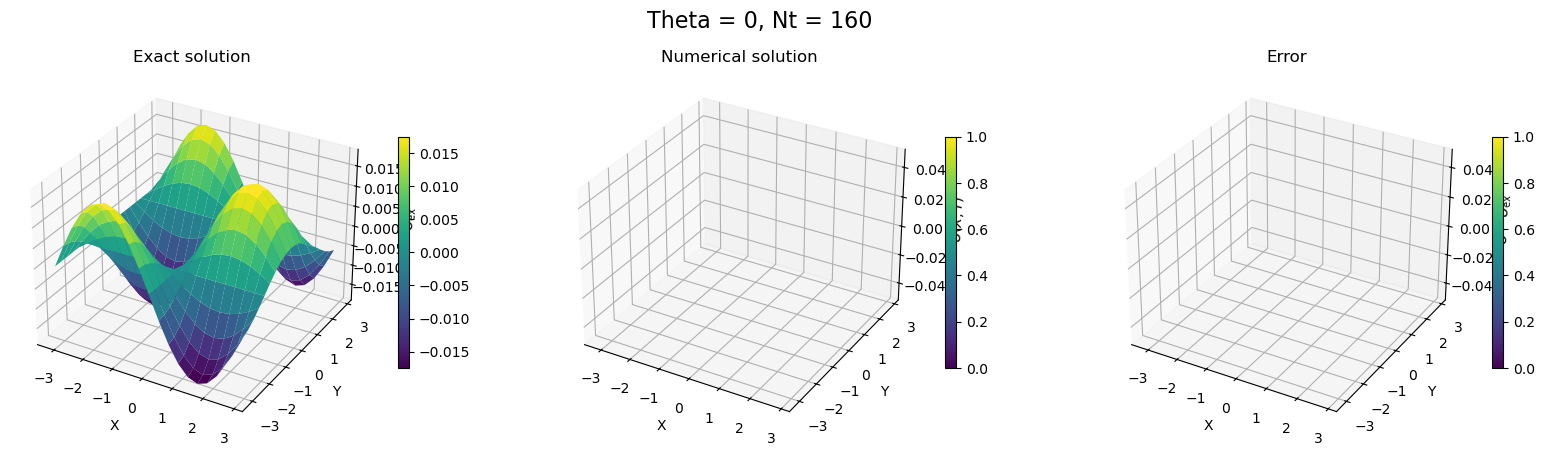

In [32]:
# Første konstruerte løsning
u_ex = lambda x, y, t: np.sin(x)*np.cos(y)*np.exp(-lam * kappa * t)

U0 = u_ex(X, Y, t0) # Initialbetingelse
theta = 1         
Nts_plot = [160]
thetas = [1, 0.5, 0]

for Nt in Nts_plot:
    for theta in thetas:
        solver = transient_biharmonic_solver(kappa=kappa, 
                                            X=X, Y=Y, U0=U0, 
                                            t0=t0, T=T, Nt=Nt,
                                            Lx=Lx, Ly=Ly,
                                            theta=theta,
                                            g=None)


        # Itererer gjennom tuple objektet som gis av funksjonen og oppdaterer slik at vi plotter løsning ved T=1
        for Uhat, t in solver: 
            
            U = ifft2(Uhat).real # Finner U i fysisk rom ved invers fourier transform
            Tfinal = t

        Uex = u_ex(X, Y, Tfinal) # Beregner eksakt løsn. ved T=1 på samme fysiske domenet som num. løsn.

        U_err = U - Uex # Finner enkel feil  til illustrasjon
        plot(Uex, U)




In [ ]:

theta = [1, 0.5, 0]         
Nt = [10, 20, 40, 80, 160, 320, 640]
table(Nt, theta, u_ex)

/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_12968/1387326174.py:28: RuntimeWarning: overflow encountered in multiply
  U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)
/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_12968/1387326174.py:28: RuntimeWarning: invalid value encountered in multiply
  U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)


,Nt,"L-inf error, θ = 1","EOC, θ = 1"
0,10,0.063237,NaN
1,20,0.033998,0.895320
2,40,0.017664,0.944656
3,80,0.009010,0.971194
4,160,0.004551,0.985292
5,320,0.002287,0.992567
6,640,0.001147,0.996263


,Nt,"L-inf error, θ = 0.5","EOC, θ = 0.5"
0,10,0.004898,NaN
1,20,0.001232,1.991623
2,40,0.000307,2.004710
3,80,0.000077,2.001173
4,160,0.000019,2.000293
5,320,0.000005,2.000073
6,640,0.000001,2.000018


,Nt,"L-inf error, θ = 0","EOC, θ = 0"
0,10,2.915717e+17,NaN
1,20,1.931232e+46,-95.741586
2,40,2.928979e+98,-173.341137
3,80,7.110034e+190,-306.896843
4,160,NaN,NaN
5,320,NaN,NaN
6,640,NaN,NaN


## Feil

In [ ]:
u_ex = lambda x, y, t: np.sin(x)*np.cos(y)*np.exp(-lam * kappa * t)
thetas = [1, 0.5, 0]
table(Nts, thetas, u_ex)

TypeError: unsupported operand type(s) for /: 'list' and 'list'

## CFL krav for stabilitet og konvergens

CFL krav forteller oss noe om sammenhengen mellom stabilitetsfunksjonen og stegstørrelse for en løsningsmetode.
Vi tar utgangspunkt i Un+1 = (1-tau(1-teta)lambda)/(1+tau* teta* lambda) * Un. Herfra kan vi se at veksten mellom steg kan måles med G, der abs(G) = abs(Un+1/Un)= abs((1-tau(1-teta)lambda)/(1+tau * teta*lambda)). Og dette forholdet burde være mindre enn 1 for å unngå at løsningen plutselig eksploderer slik den gjør i stive problemer. Ser vi på teta = 0 ser vi at vi må ha abs(1-tau * lambda)<=1 og dermed 0<= tau * lamda <= 2. Med lambda lik kappa * k4 slik den er for den biharmoniske operator, gir dette kravet tau <= 2/(kappa * k4). Altså Nt > kappa *k4/2. Vi finner dette ved å begrense med Ncfl = k4max / 2

In [47]:
# Lager frekvensrommet
Nx, Ny = X.shape 
kx = fftfreq(Nx, d=Lx/Nx)*2*np.pi
ky = fftfreq(Ny, d=Ly/Ny)*2*np.pi
KX, KY = np.meshgrid(kx, ky, sparse=True)

# Definerer k**4 til senere bruk
k4 = (KX**2 + KY**2)**2
Ncfl = int(np.max(k4)/2)

theta = 0
Ncfls = [int(0.5*Ncfl), Ncfl, 2*Ncfl, 4*Ncfl]

u_ex = lambda x, y, t: np.sin(x)*np.cos(y)*np.exp(-lam * kappa * t)
theta = [1]         
table(Ncfls, theta, u_ex)

,Nt,"L-inf error, θ = 1","EOC, θ = 1"
0,10000,0.000074,NaN
1,20000,0.000037,0.99988
2,40000,0.000018,0.99994
3,80000,0.000009,0.99997


## Inhomogen likning

In [51]:
# Bruker kode fra forelesningsnotater for å finne g
def manufacture_solution_biharmonic(u_str, kappa, M, f):
    import sympy as sy
    from sympy import sin, cos, exp
    x, y, t = sy.symbols('x y t')
    u_sy = eval(u_str) # symbolsk representasjon av u evalueres fra strengen
    laplace = lambda u: sy.diff(u, x, x) + sy.diff(u, y, y) # Definerer laplace
    g_sy =  sy.diff(u_sy, t) - sy.simplify(M*laplace(f(u_sy)))+sy.simplify(kappa*(laplace(laplace(u_sy))))  # skriver uttrykk for g
    
    # funksjonene gjøres til kallbare funksjoner og printes
    u = sy.lambdify((x, y, t), u_sy, modules='numpy') 
    g = sy.lambdify((x, y, t), g_sy, modules='numpy')
    print(f'u = {u_sy}') 
    print(f'u0 = {u_sy.subs(t, 0)}')
    print(f'g = {g_sy}')
    return u, g

M = 1
f = lambda u : u**3 - u
u_ex_str = '(exp(1+sin(x)*sin(x))+exp(1+cos(y)*cos(y)))*exp(-4*kappa*t)'
u_ex, g = manufacture_solution_biharmonic(u_ex_str, kappa, M, f)

u = (exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*t)
u0 = exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1)
g = -4*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*t) + 4*(4*exp(1 - sin(y)**2)*sin(y)**8 - 32*exp(1 - sin(y)**2)*sin(y)**6 + 68*exp(1 - sin(y)**2)*sin(y)**4 - 44*exp(1 - sin(y)**2)*sin(y)**2 + 5*exp(1 - sin(y)**2) + 4*exp(sin(x)**2)*sin(x)**8 + 16*exp(sin(x)**2)*sin(x)**6 - 4*exp(sin(x)**2)*sin(x)**4 - 12*exp(sin(x)**2)*sin(x)**2 + exp(sin(x)**2))*exp(1 - 4*t) - 2*(6*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(sin(x)**2 + 1)*sin(x)**2*cos(x)**2 - 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(sin(x)**2 + 1)*sin(x)**2 + 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(sin(x)**2 + 1)*cos(x)**2 + 6*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(cos(y)**2 + 1)*sin(y)**2*cos(y)**2 + 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(cos(y)**2 + 1)*sin(y)**2 - 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(cos(y)**2 + 1)*cos(y)**2 + 12*(exp(sin(x)**2 + 1) + exp(cos(y)**

In [2]:
# Kopierer tidligere løsning så vi slipper å kjøre blokken over gjentatte ganger
u_ex_inhomo = lambda x, y, t: (np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(-4*t)
g = lambda x, y, t: -4*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(-4*t) + 4*(4*np.exp(1 - np.sin(y)**2)*np.sin(y)**8 - 32*np.exp(1 - np.sin(y)**2)*np.sin(y)**6 + 68*np.exp(1 - np.sin(y)**2)*np.sin(y)**4 - 44*np.exp(1 - np.sin(y)**2)*np.sin(y)**2 + 5*np.exp(1 - np.sin(y)**2) + 4*np.exp(np.sin(x)**2)*np.sin(x)**8 + 16*np.exp(np.sin(x)**2)*np.sin(x)**6 - 4*np.exp(np.sin(x)**2)*np.sin(x)**4 - 12*np.exp(np.sin(x)**2)*np.sin(x)**2 + np.exp(np.sin(x)**2))*np.exp(1 - 4*t) - 2*(6*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.sin(x)**2 + 1)*np.sin(x)**2*np.cos(x)**2 - 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.sin(x)**2 + 1)*np.sin(x)**2 + 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.sin(x)**2 + 1)*np.cos(x)**2 + 6*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.cos(y)**2 + 1)*np.sin(y)**2*np.cos(y)**2 + 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.cos(y)**2 + 1)*np.sin(y)**2 - 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.cos(y)**2 + 1)*np.cos(y)**2 + 12*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(3 - np.cos(2*x))*np.sin(x)**2*np.cos(x)**2 + 12*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(np.cos(2*y) + 3)*np.sin(y)**2*np.cos(y)**2 + (2*np.sin(x)**4 - 1)*np.exp(8*t + np.sin(x)**2 + 1) + (2*np.sin(y)**4 - 4*np.sin(y)**2 + 1)*np.exp(8*t + np.cos(y)**2 + 1))*np.exp(-12*t)

In [3]:
Nts = [10, 20, 40, 80, 160, 320, 640]
thetas = [0.5, 1]
table(Nts, thetas, u_ex, g)


NameError: name 'table' is not defined

# Trond sine greier

In [4]:
from scipy.fft import fft, ifft, fft2, ifft2, fftfreq, fftshift
import sympy as sp

def transient_biharmonic_solver(*, kappa, 
                                   X, Y, U0, 
                                   t0, T, Nt, 
                                   theta=0.5,
                                   g=None):
    """
    Solve the transient biharmonic equation using the theta method.

    Parameters:
    ----------- 
    kappa (float): Diffusion coefficient.
    X (ndarray): 2D array of x-coordinates.
    Y (ndarray): 2D array of y-coordinates.
    U0 (ndarray): Initial condition array.
    t0 (float): Initial time.
    T (float): Final time.
    Nt (int): Number of time steps.
    g (callable, optional): Source term function g(X, Y, t). Defaults to None.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.
    """

    # Prepare relevant data for Fourier transform
    N, M = U0.shape  # U0 is a NxM matrix, but in python .shape gives them in reverse order
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))

    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")
    K4 = ((KX**2 + KY**2)**2)

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Add your time-stepping loop here
    # Time stepping 
    t = t0 
    dt = (T-t0)/Nt

    # For convenience when plotting, computing errors, etc., 
    # return the initial solution and initial time.
    yield U_hat, t    
    
    while t < T-dt/2:
        # Compute source term in Fourier space if provided
        if g is not None:
            g_now = fft2(g(X, Y, t))        # g(n)
            g_next = fft2(g(X , Y, t+dt))   # g(n+1)
        else:
            g_now, g_next = 0, 0
        
        
        # Implicit treatment (theta > 0)
        denominator = 1 + theta * dt * kappa * K4
        numerator = (1 - (1 - theta) * dt * kappa * K4) * U_hat + dt * (theta * g_next + (1 - theta) * g_now)
        U_hat = numerator / denominator
        

        # Update time
        t += dt

        yield U_hat, t

#### Beregningsmessig oppgave 2

In [5]:
def U_ex1(x, y, t):
    return np.sin(x) * np.cos(y) * np.exp(-lam * kappa * t)

x, y, t, lam, kappa = sp.symbols("x y t lam kappa")
u_ex1 = sp.sin(x) * sp.cos(y) * sp.exp(- lam * kappa * t)
laplacian_u1 = sp.diff(u_ex1, x, 2) + sp.diff(u_ex1, y, 2)
biharmonic_u1 = sp.diff(laplacian_u1, x, 2) + sp.diff(laplacian_u1, y, 2)
g = sp.diff(u_ex1, t) + kappa * biharmonic_u1
g_simplified = sp.simplify(g)
sp.pprint(g_simplified)

             -κ⋅lam⋅t              
κ⋅(4 - lam)⋅ℯ        ⋅sin(x)⋅cos(y)


In [7]:
import numpy as np
lam = 4 # Setter lambda = 4, for at g = 0
kappa = 1
t0, T = 0, 1
Nts = [10, 20, 40, 80, 160, 320, 640]

thetas = [0, 0.5, 1]
N = 20
x, y = np.linspace(-np.pi, np.pi, N, endpoint=False), np.linspace(-np.pi, np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
U0 = U_ex1(X, Y, 0)


for theta in thetas:

    errors = []
    hs = []
    for Nt in Nts:
        dt = (T - t0) / Nt
        solver = transient_biharmonic_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, theta=theta, g=None)
        max_error = 0
        for Uhat, t in solver:
            U = ifft2(Uhat).real
            new_error = np.max(np.abs(U - U_ex1(X, Y, t)))
            if new_error > max_error:
                max_error = new_error
        
        errors.append(max_error)
        hs.append(dt)

    # Compute EOC
    eocs = []

    for i in range(1, len(errors)):
        # print(errors[i]), print(errors[i-1]), print(hs[i]), print(hs[i-1])
        # print(np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1]))
        eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])
        eocs.append(eoc)

    # Print results in a table
    print(f"\nConvergence Table for theta = {theta}:")
    print(f"{'Nt':<10}{'Max Error':<20}{'EOC':<10}")
    print("-" * 40)
    for i, Nt in enumerate(Nts):
        if i == 0:
            print(f"{Nt:<10}{errors[i]:<20.2e}{'-':<10}")
        else:
            print(f"{Nt:<10}{errors[i]:<20.2e}{eocs[i-1]:<10.2f}")

/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_42093/369100806.py:61: RuntimeWarning: overflow encountered in multiply
  numerator = (1 - (1 - theta) * dt * kappa * K4) * U_hat + dt * (theta * g_next + (1 - theta) * g_now)
/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_42093/369100806.py:62: RuntimeWarning: invalid value encountered in divide
  U_hat = numerator / denominator
/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_42093/369100806.py:61: RuntimeWarning: invalid value encountered in multiply
  numerator = (1 - (1 - theta) * dt * kappa * K4) * U_hat + dt * (theta * g_next + (1 - theta) * g_now)



Convergence Table for theta = 0:
Nt        Max Error           EOC       
----------------------------------------
10        2.18e+18            -         
20        2.69e+47            -96.64    
40        4.50e+99            -173.48   
80        1.09e+192           -306.90   
160       1.29e+304           -372.29   
320       1.24e+304           0.05      
640       4.00e+304           -1.69     

Convergence Table for theta = 0.5:
Nt        Max Error           EOC       
----------------------------------------
10        4.90e-03            -         
20        1.23e-03            1.99      
40        3.07e-04            2.00      
80        7.67e-05            2.00      
160       1.92e-05            2.00      
320       4.79e-06            2.00      
640       1.20e-06            2.00      

Convergence Table for theta = 1:
Nt        Max Error           EOC       
----------------------------------------
10        6.32e-02            -         
20        3.40e-02            0.90 

In [8]:
lam = 4 # Setter lambda = 4, for at g = 0
kappa = 1
t0, T = 0, 1

theta = 0
N = 20
x, y = np.linspace(-np.pi, np.pi, N, endpoint=False), np.linspace(-np.pi, np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
U0 = U_ex1(X, Y, 0)

Nt_CFL = (T - t0) * kappa * 2 * (2* np.pi * N)**2 + 10
Nts = [int(0.5*Nt_CFL), int(Nt_CFL), int(2*Nt_CFL), int(4*Nt_CFL)]


errors = []
hs = []
for Nt in Nts:
    dt = (T - t0) / Nt
    solver = transient_biharmonic_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, theta=theta, g=None)
    max_error = 0
    for Uhat, t in solver:
        U = ifft2(Uhat).real
        new_error = np.max(np.abs(U - U_ex1(X, Y, t)))
        if new_error > max_error:
            max_error = new_error
    
    errors.append(max_error)
    hs.append(dt)

# Compute EOC
eocs = []

for i in range(1, len(errors)):
    # print(errors[i]), print(errors[i-1]), print(hs[i]), print(hs[i-1])
    # print(np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1]))
    eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])
    eocs.append(eoc)

# Print results in a table
print(f"\nConvergence Table for theta = {theta}:")
print(f"{'Nt':<10}{'Max Error':<20}{'EOC':<10}")
print("-" * 40)
for i, Nt in enumerate(Nts):
    if i == 0:
        print(f"{Nt:<10}{errors[i]:<20.2e}{'-':<10}")
    else:
        print(f"{Nt:<10}{errors[i]:<20.2e}{eocs[i-1]:<10.2f}")

/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_42093/369100806.py:61: RuntimeWarning: overflow encountered in multiply
  numerator = (1 - (1 - theta) * dt * kappa * K4) * U_hat + dt * (theta * g_next + (1 - theta) * g_now)
/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_42093/369100806.py:62: RuntimeWarning: invalid value encountered in divide
  U_hat = numerator / denominator
/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_42093/369100806.py:61: RuntimeWarning: invalid value encountered in multiply
  numerator = (1 - (1 - theta) * dt * kappa * K4) * U_hat + dt * (theta * g_next + (1 - theta) * g_now)


KeyboardInterrupt: 

In [9]:
def U_ex2(x, y, t):
    return (np.exp(1 + np.sin(x)**2) + np.exp(1 + np.cos(y)**2))*np.exp(-4*kappa*t)

x, y, t, lam, kappa = sp.symbols("x y t lam kappa")
u_ex2 = (sp.exp(1 + sp.sin(x)**2) + sp.exp(1 + sp.cos(y)**2))*sp.exp(-4*kappa*t)
laplacian_u2 = sp.diff(u_ex2, x, 2) + sp.diff(u_ex2, y, 2)
biharmonic_u2 = sp.diff(laplacian_u2, x, 2) + sp.diff(laplacian_u2, y, 2)
g = sp.diff(u_ex2, t) + kappa * biharmonic_u2
g_simplified = sp.simplify(g)
sp.pprint(g_simplified)

     ⎛        2                        2                         2            
     ⎜ 1 - sin (y)    8         1 - sin (y)    6          1 - sin (y)    4    
16⋅κ⋅⎝ℯ           ⋅sin (y) - 8⋅ℯ           ⋅sin (y) + 17⋅ℯ           ⋅sin (y) 

             2                      2          2                    2         
      1 - sin (y)    2       1 - sin (y)    sin (x)    8         sin (x)    6 
- 11⋅ℯ           ⋅sin (y) + ℯ            + ℯ       ⋅sin (x) + 4⋅ℯ       ⋅sin (

         2                    2           ⎞            
      sin (x)    4         sin (x)    2   ⎟  -4⋅κ⋅t + 1
x) - ℯ       ⋅sin (x) - 3⋅ℯ       ⋅sin (x)⎠⋅ℯ          


In [10]:
kappa = 1
t0, T = 0, 1
Nts = [10, 20, 40, 80, 160, 320, 640]

thetas = [0, 0.5, 1]
N = 20
x, y = np.linspace(-np.pi, np.pi, N, endpoint=False), np.linspace(-np.pi, np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
U0 = U_ex1(X, Y, 0)


for theta in thetas:

    errors = []
    hs = []
    for Nt in Nts:
        dt = (T - t0) / Nt
        solver = transient_biharmonic_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, theta=theta, g=None)
        max_error = 0
        for Uhat, t in solver:
            U = ifft2(Uhat).real
            new_error = np.max(np.abs(U - U_ex(X, Y, t)))
            if new_error > max_error:
                max_error = new_error
        
        errors.append(max_error)
        hs.append(dt)

    # Compute EOC
    eocs = []

    for i in range(1, len(errors)):
        # print(errors[i]), print(errors[i-1]), print(hs[i]), print(hs[i-1])
        # print(np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1]))
        eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])
        eocs.append(eoc)

    # Print results in a table
    print(f"\nConvergence Table for theta = {theta}:")
    print(f"{'Nt':<10}{'Max Error':<20}{'EOC':<10}")
    print("-" * 40)
    for i, Nt in enumerate(Nts):
        if i == 0:
            print(f"{Nt:<10}{errors[i]:<20.2e}{'-':<10}")
        else:
            print(f"{Nt:<10}{errors[i]:<20.2e}{eocs[i-1]:<10.2f}")

TypeError: loop of ufunc does not support argument 0 of type Zero which has no callable exp method